# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** ShrriDharshan S
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 3
- **Date:** 20/07/2026

---


In [1]:
# Step 1 — Student Details

STUDENT_NAME = "ShrriDharshan S"
REG_NO = "23BPS1090"
COURSE_CODE = "BCSE209P-Machine Learning Laboratory"
FACULTY_NAME = "Dr. S. Shridevi"
COLLEGE = "SCOPE, VIT Chennai"
LAB_ID = "ML-LAB-03"

print("Notebook initialised successfully")


Notebook initialised successfully


In [2]:
# Step 2 — Notebook Fingerprint

import hashlib
import datetime

fp = hashlib.sha256(
    (STUDENT_NAME + REG_NO + COURSE_CODE + LAB_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fp)


Notebook Fingerprint:
dfdb2a603d9ab75a8c34fb4e8ee99dd92da51674a1fc65b097810f4982524acd


# Experiment Details

## Objective

To apply **Simple Linear Regression (SLR)** and **Multiple Linear Regression (MLR)** on the *Paddy Dataset* (UCI ML Repository, ID: 1186) for predicting a paddy yield or production-related quantity from cultivation attributes such as area, seed rate, manure, soil type, and paddy variety, and to compare both models using MAE, MSE, RMSE, and R².

## Theory

Paddy yield is influenced by a combination of numeric inputs — land area, seed rate, and manure quantity — as well as categorical factors like soil type and paddy variety. This makes it a suitable **multiple regression** problem where the output is continuous and multiple predictors are available.

**Simple Linear Regression** models the target using only one predictor — cultivated area in hectares:

$$\hat{y} = \beta_0 + \beta_1 \cdot \text{Hectares}$$

**Multiple Linear Regression** incorporates several numeric inputs along with **one-hot encoded categorical columns** (variety, soil type, etc.) to form a richer model:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

**Performance metrics used:** MAE, MSE, RMSE, and R².

## Dataset

- **Name:** Paddy Dataset
- **Source:** UCI Machine Learning Repository (ID: 1186) — https://archive.ics.uci.edu/dataset/1186/
- **Instances:** 2,790
- **Features:** 45 (a mix of categorical and numeric columns)
- **Missing values:** None reported
- **Licence:** CC BY 4.0
- **Citation:** Subramaniyan, M. (2023). *Paddy Dataset* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55W3J

> **Note on target column:** The UCI preview only exposes 10 of the 45 columns. The code below downloads the full file, lists all 45 column names, and automatically identifies a yield/production-type numeric column as `TARGET_COL`. After running Step 3, verify this column matches what your faculty has specified.

## Algorithm Steps

1. Download and load `paddydataset.csv` from UCI.
2. Print all column names and auto-select the regression target.
3. Check dataset shape, dtypes, missing values, and duplicates.
4. EDA: distribution of target, numeric correlations, scatter plots.
5. **SLR:** train `LinearRegression` using `Hectares` only.
6. **MLR:** one-hot encode categoricals, scale features, train `LinearRegression`.
7. Evaluate both models, visualize predictions and residuals, compare results.

## Expected Outcome

- SLR using land area alone gives a basic linear baseline.
- MLR incorporating additional numeric and categorical inputs is expected to produce a **higher R² and lower RMSE**, since yield depends on more factors than area alone.


In [3]:
# Step 3 — Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

print("All libraries loaded successfully")


All libraries loaded successfully


In [4]:
# Step 4 — Download and Load the UCI Paddy Dataset

DATASET_URL = "https://archive.ics.uci.edu/static/public/1186/paddy+dataset.zip"

SAVE_DIR = "paddy_data"
os.makedirs(SAVE_DIR, exist_ok=True)

zip_file_path = os.path.join(SAVE_DIR, "dataset.zip")

# Check for corrupted zip before using it
if os.path.exists(zip_file_path):
    try:
        with zipfile.ZipFile(zip_file_path) as zf:
            zf.testzip()
    except zipfile.BadZipFile:
        print("Corrupted zip detected — removing and re-downloading ...")
        os.remove(zip_file_path)

if not os.path.exists(zip_file_path):
    print("Downloading dataset from UCI repository ...")
    urllib.request.urlretrieve(DATASET_URL, zip_file_path)
    print("Download complete")
else:
    print("Archive already present — skipping download")

with zipfile.ZipFile(zip_file_path) as zf:
    zf.extractall(SAVE_DIR)
    print("Extracted files:", zf.namelist())

csv_files = [f for f in os.listdir(SAVE_DIR) if f.lower().endswith(".csv")]
csv_file_path = os.path.join(SAVE_DIR, csv_files[0])
print("\nCSV located at:", csv_file_path)

df = pd.read_csv(csv_file_path)
df.columns = [str(c).strip() for c in df.columns]

print("\nDataset loaded successfully")
print("Shape:", df.shape)
print("\nAll column names:")
print(df.columns.tolist())


Download complete
Extracted files: ['paddydataset.csv']

CSV located at: paddy_data\paddydataset.csv

Dataset loaded successfully
Shape: (2789, 45)

All column names:
['Hectares', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind Direction_D61_D90', 'Wind Directio

In [5]:
# Step 5 — Auto-detect Target Column (yield / production type)

search_keywords = ["yield", "production", "output", "harvest", "quintal"]

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

matched = [c for c in num_cols
           if any(kw in c.lower() for kw in search_keywords)]

if matched:
    TARGET_COL = matched[0]
    print("Target column identified by name match:", TARGET_COL)
else:
    id_like = [c for c in num_cols if "id" in c.lower()]
    pool = [c for c in num_cols if c not in id_like]
    TARGET_COL = df[pool].var().idxmax()
    print("WARNING: No keyword match found for yield/production.")
    print("Using highest-variance numeric column as fallback:", TARGET_COL)
    print("  --> Verify this is the correct target before proceeding.")

print("\nTARGET_COL =", TARGET_COL)
print(df[TARGET_COL].describe())


Target column identified by name match: Paddy yield(in Kg)

TARGET_COL = Paddy yield(in Kg)
count     2789.000000
mean     22517.728935
std       9199.661393
min       5410.000000
25%      16389.000000
50%      24636.000000
75%      31035.000000
max      38814.000000
Name: Paddy yield(in Kg), dtype: float64


In [6]:
# Step 6 — Dataset Summary

print("Dataset Name  : Paddy Dataset")
print("Total Samples :", df.shape[0])
print("Total Features:", df.shape[1] - 1, " (excluding target:", TARGET_COL, ")")
print("Source        : UCI ML Repository — ID 1186")
print("URL           : https://archive.ics.uci.edu/dataset/1186/")


Dataset Name  : Paddy Dataset
Total Samples : 2789
Total Features: 44  (excluding target: Paddy yield(in Kg) )
Source        : UCI ML Repository — ID 1186
URL           : https://archive.ics.uci.edu/dataset/1186/


In [7]:
# Step 7 — Basic Data Inspection

print("Dataset Info:")
df.info()

print("\nData Type Counts:")
print(df.dtypes.value_counts())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows Found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   str    
 2   Variety                             2789 non-null   str    
 3   Soil Types                          2789 non-null   str    
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   str    
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789

In [8]:
# Step 8 — Descriptive Statistics

print("Numeric feature statistics:")
print(df.select_dtypes(include=[np.number]).describe().T)

print("\nCategorical column cardinality (top 10):")
cat_all = df.select_dtypes(include=["object"]).columns
print(df[cat_all].nunique().sort_values(ascending=False).head(10))


Numeric feature statistics:
                                     count          mean          std  \
Hectares                            2338.0      3.736099     1.450388   
Seedrate(in Kg)                     2338.0     93.402481    36.259703   
LP_Mainfield(in Tonnes)             2338.0     46.701240    18.129851   
Nursery area (Cents)                2338.0     74.721985    29.007762   
LP_nurseryarea(in Tonnes)           2338.0      3.736099     1.450388   
DAP_20days                          2338.0    149.443969    58.015525   
Weed28D_thiobencarb                 2338.0      7.472198     2.900776   
Urea_40Days                         2338.0    101.360372    39.349030   
Potassh_50Days                      2338.0     38.780710    15.055029   
Micronutrients_70Days               2338.0     56.041488    21.755822   
Pest_60Day(in ml)                   2338.0   2241.659538   870.232869   
30DRain( in mm)                     2338.0     18.712789     0.640051   
30DAI(in mm)           

C:\Users\shrri\AppData\Local\Temp\ipykernel_6248\3167101517.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_all = df.select_dtypes(include=["object"]).columns


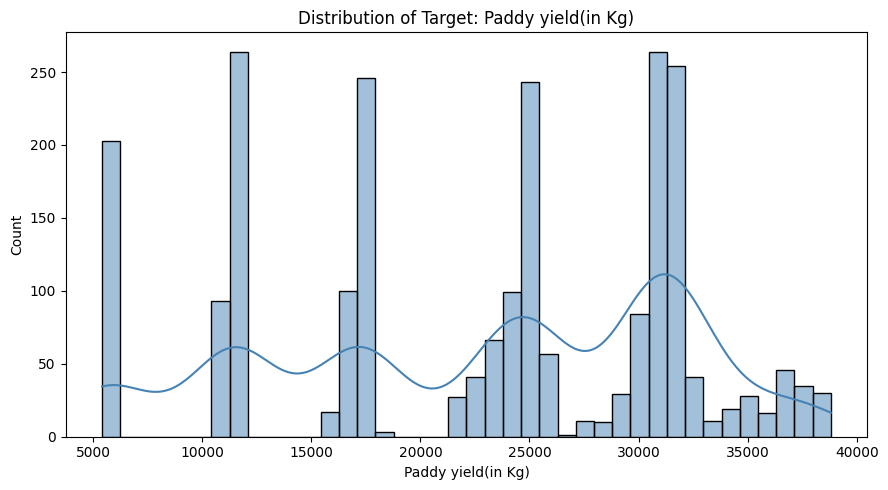

In [9]:
# Step 9 — Target Variable Distribution

plt.figure(figsize=(9, 5))
sns.histplot(df[TARGET_COL], bins=40, kde=True, color="steelblue")
plt.xlabel(TARGET_COL)
plt.title(f"Distribution of Target: {TARGET_COL}")
plt.tight_layout()
plt.show()


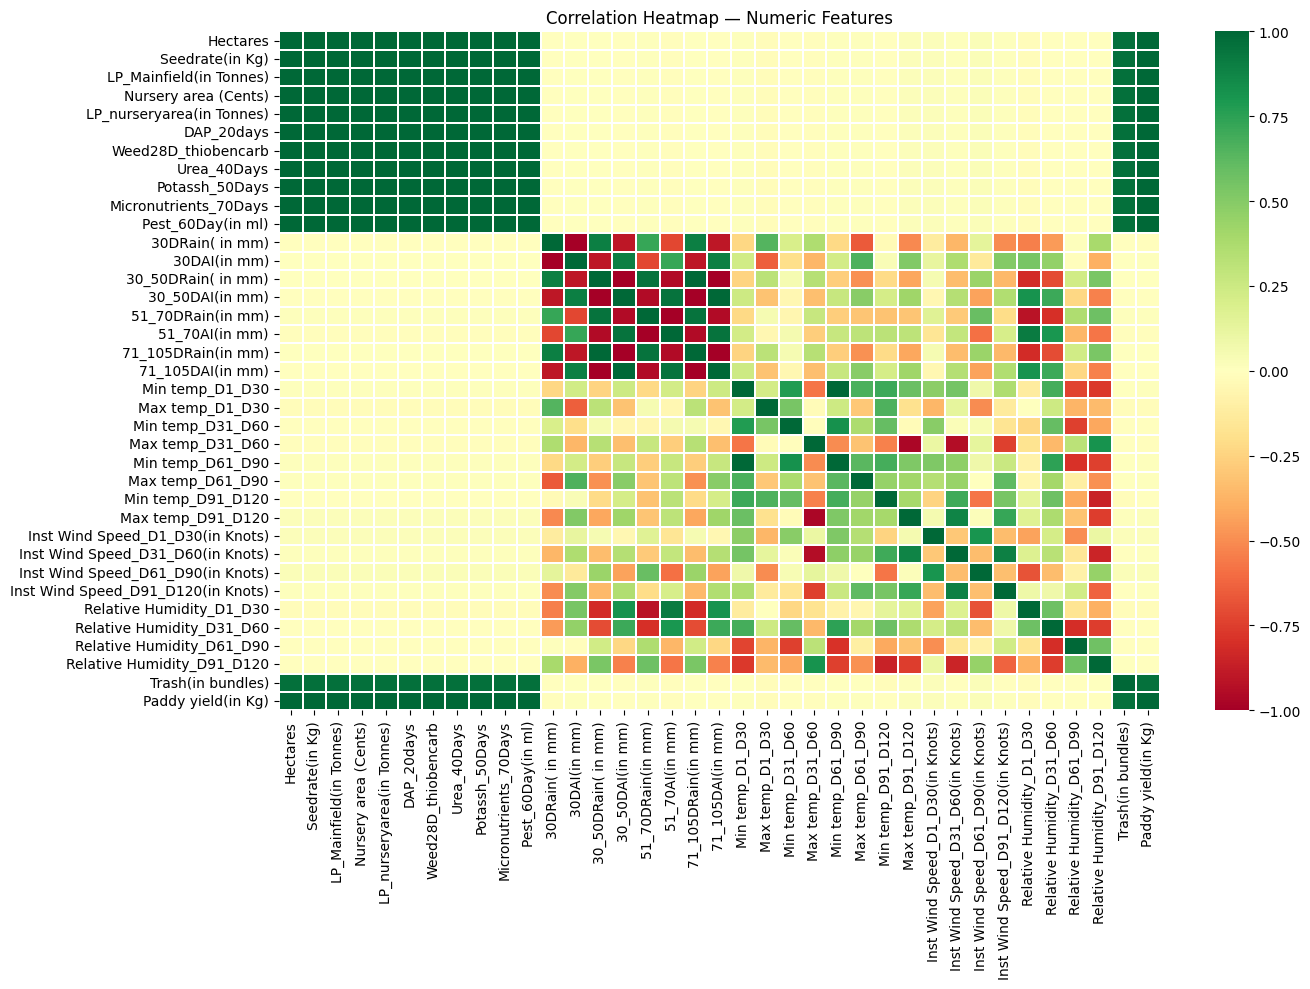

Correlation with target column:
Paddy yield(in Kg)           1.000000
Pest_60Day(in ml)            0.994339
Urea_40Days                  0.994339
LP_nurseryarea(in Tonnes)    0.994339
Hectares                     0.994339
Weed28D_thiobencarb          0.994339
Micronutrients_70Days        0.994339
Nursery area (Cents)         0.994339
DAP_20days                   0.994339
Seedrate(in Kg)              0.994339
Name: Paddy yield(in Kg), dtype: float64


In [10]:
# Step 10 — Numeric Feature Correlations

numeric_frame = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_frame.corr(), cmap="RdYlGn", center=0, linewidths=0.3)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

print("Correlation with target column:")
print(numeric_frame.corr()[TARGET_COL].sort_values(ascending=False).head(10))


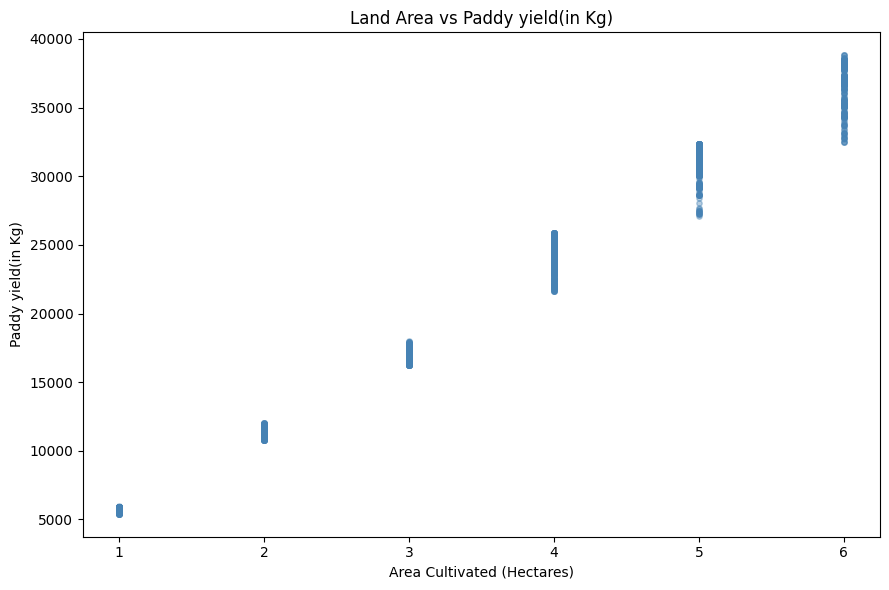

In [11]:
# Step 11 — Scatter Plot: Hectares vs Target

plt.figure(figsize=(9, 6))
plt.scatter(df["Hectares"], df[TARGET_COL], alpha=0.4, s=15, color="steelblue")
plt.xlabel("Area Cultivated (Hectares)")
plt.ylabel(TARGET_COL)
plt.title(f"Land Area vs {TARGET_COL}")
plt.tight_layout()
plt.show()


---
# Implementation

## Part A — Simple Linear Regression (SLR)

Predict the target using only `Hectares` (cultivated land area) as the sole predictor.


In [12]:
# Step 12 — Prepare Data for SLR

X_slr = df[["Hectares"]]
y_target = df[TARGET_COL]

X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(
    X_slr, y_target, test_size=0.20, random_state=42
)

print("Train size:", X_train_slr.shape[0])
print("Test size :", X_test_slr.shape[0])


Train size: 1870
Test size : 468


In [13]:
# Step 13 — Train Simple Linear Regression Model

slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train_slr)

y_pred_slr = slr_model.predict(X_test_slr)

mae_slr  = mean_absolute_error(y_test_slr, y_pred_slr)
mse_slr  = mean_squared_error(y_test_slr, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr   = r2_score(y_test_slr, y_pred_slr)

print("=== SIMPLE LINEAR REGRESSION RESULTS ===")
print(f"Equation: {TARGET_COL} = "
      f"{slr_model.intercept_:.3f} + {slr_model.coef_[0]:.3f} * Hectares")
print("MAE  :", mae_slr)
print("MSE  :", mse_slr)
print("RMSE :", rmse_slr)
print("R²   :", r2_slr)


=== SIMPLE LINEAR REGRESSION RESULTS ===
Equation: Paddy yield(in Kg) = -1094.732 + 6345.537 * Hectares
MAE  : 762.5976223913735
MSE  : 1068463.756978936
RMSE : 1033.6652054601316
R²   : 0.9875193983837608


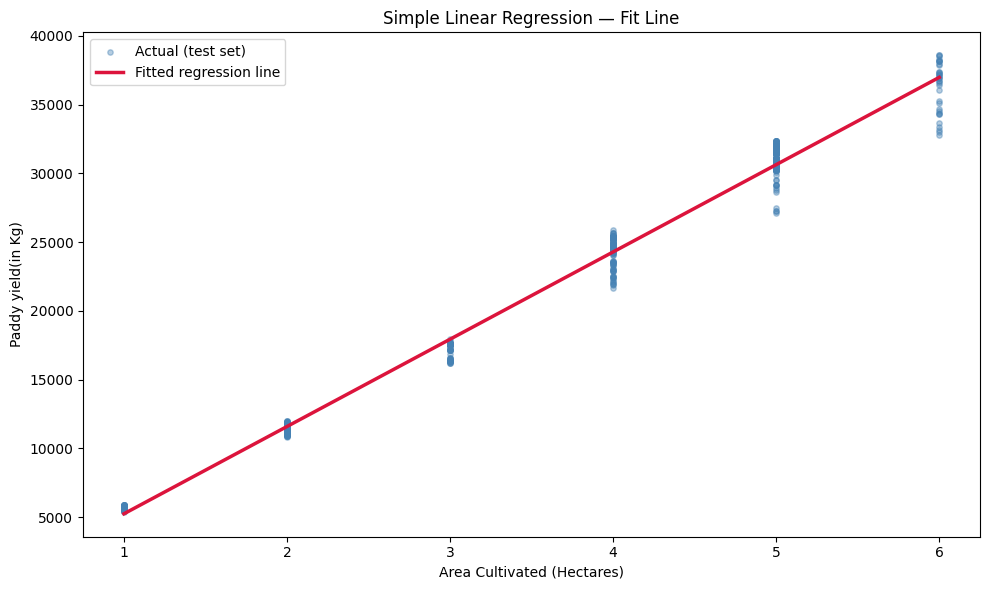

In [14]:
# Step 14 — Plot SLR Regression Line

X_sorted = X_test_slr.sort_values(by="Hectares")
y_line   = slr_model.predict(X_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(X_test_slr["Hectares"], y_test_slr,
            alpha=0.4, s=15, color="steelblue", label="Actual (test set)")
plt.plot(X_sorted["Hectares"], y_line,
         color="crimson", linewidth=2.5, label="Fitted regression line")
plt.xlabel("Area Cultivated (Hectares)")
plt.ylabel(TARGET_COL)
plt.title("Simple Linear Regression — Fit Line")
plt.legend()
plt.tight_layout()
plt.show()


## Part B — Multiple Linear Regression (MLR)

Predict the target using multiple numeric cultivation inputs along with one-hot encoded categorical columns (soil type, paddy variety, nursery type, etc.).


In [15]:
# Step 15 — Feature Engineering: Numeric + One-Hot Categorical

numeric_frame = df.select_dtypes(include=[np.number])
num_predictors = [c for c in numeric_frame.columns if c != TARGET_COL]

# Use only low-cardinality categorical columns to avoid a huge sparse matrix
cat_predictors = [c for c in df.select_dtypes(include=["object"]).columns
                  if df[c].nunique() <= 15]

print("Numeric predictors:", num_predictors)
print("\nCategorical predictors (one-hot encoded):", cat_predictors)

X_num  = df[num_predictors]
X_cat  = pd.get_dummies(df[cat_predictors], drop_first=True)

X_mlr  = pd.concat([X_num, X_cat], axis=1)
y_mlr  = df[TARGET_COL]

print("\nCombined feature matrix shape:", X_mlr.shape)


Numeric predictors: ['Hectares', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(in bundles)']

Categorical predictors (one-hot encoded): ['Agriblock', 'Variety', 'Soil Types', 'Nursery', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind 

C:\Users\shrri\AppData\Local\Temp\ipykernel_6248\2026829966.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_predictors = [c for c in df.select_dtypes(include=["object"]).columns


In [16]:
# Step 16 — Train Multiple Linear Regression Model

X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    X_mlr, y_mlr, test_size=0.20, random_state=42
)

feat_scaler = StandardScaler()
X_train_sc  = feat_scaler.fit_transform(X_train_mlr)
X_test_sc   = feat_scaler.transform(X_test_mlr)

mlr_model = LinearRegression()
mlr_model.fit(X_train_sc, y_train_mlr)

y_pred_mlr = mlr_model.predict(X_test_sc)

mae_mlr  = mean_absolute_error(y_test_mlr, y_pred_mlr)
mse_mlr  = mean_squared_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr   = r2_score(y_test_mlr, y_pred_mlr)

print("=== MULTIPLE LINEAR REGRESSION RESULTS ===")
print("MAE  :", mae_mlr)
print("MSE  :", mse_mlr)
print("RMSE :", rmse_mlr)
print("R²   :", r2_mlr)


=== MULTIPLE LINEAR REGRESSION RESULTS ===
MAE  : 768.3663327907942
MSE  : 1040176.3606661889
RMSE : 1019.8903669837209
R²   : 0.9878498201896799


Intercept: 22533.06256684492
                      Feature  Coefficient
35          Trash(in bundles) -1637.136336
3        Nursery area (Cents)   981.380955
4   LP_nurseryarea(in Tonnes)   981.380955
0                    Hectares   981.380955
9       Micronutrients_70Days   981.380955
7                 Urea_40Days   981.380955
10          Pest_60Day(in ml)   981.380955
8              Potassh_50Days   981.380955
1             Seedrate(in Kg)   981.380955
2     LP_Mainfield(in Tonnes)   981.380955
6         Weed28D_thiobencarb   981.380955
5                  DAP_20days   981.380955
41        Variety_delux ponni  -161.676039
42            Variety_ponmani   147.098111
44                Nursery_wet    31.282754


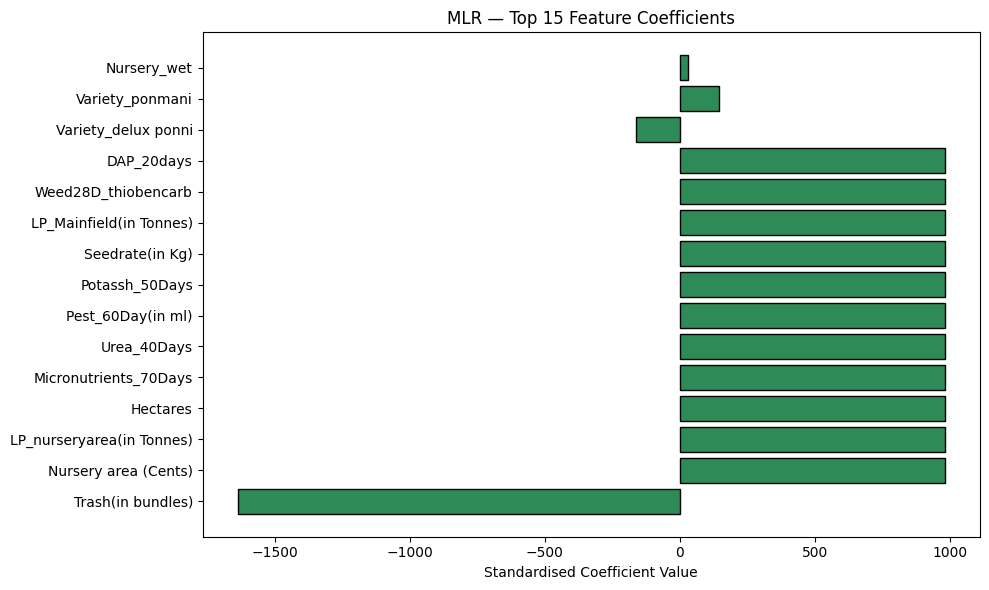

In [17]:
# Step 17 — Top Feature Coefficients (MLR)

coeff_df = pd.DataFrame({
    "Feature"    : X_mlr.columns,
    "Coefficient": mlr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Intercept:", mlr_model.intercept_)
print(coeff_df.head(15))

top15 = coeff_df.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top15["Feature"], top15["Coefficient"],
         color="seagreen", edgecolor="black")
plt.xlabel("Standardised Coefficient Value")
plt.title("MLR — Top 15 Feature Coefficients")
plt.tight_layout()
plt.show()


---
# Results


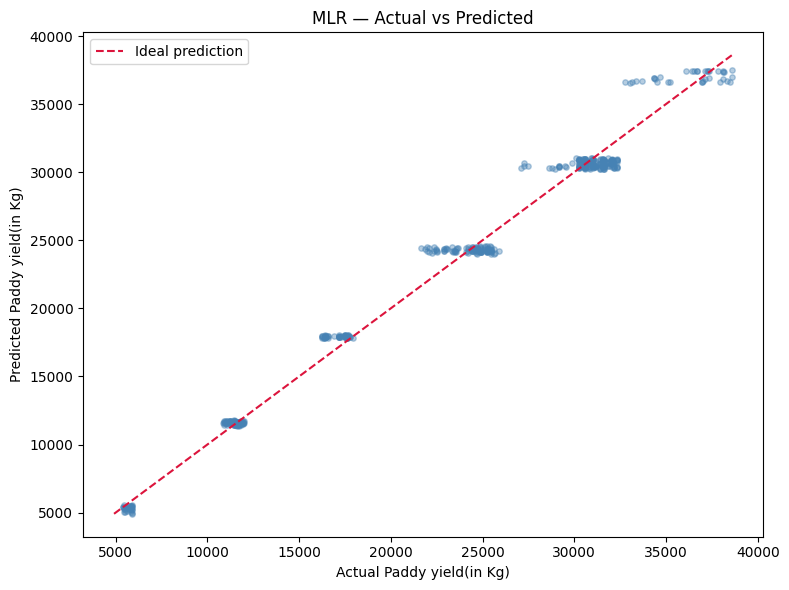

In [18]:
# Step 18 — Actual vs Predicted Plot (MLR)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_mlr, y_pred_mlr, alpha=0.4, s=15, color="steelblue")

lo = min(y_test_mlr.min(), y_pred_mlr.min())
hi = max(y_test_mlr.max(), y_pred_mlr.max())
plt.plot([lo, hi], [lo, hi], linestyle="--",
         color="crimson", label="Ideal prediction")

plt.xlabel(f"Actual {TARGET_COL}")
plt.ylabel(f"Predicted {TARGET_COL}")
plt.title("MLR — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()


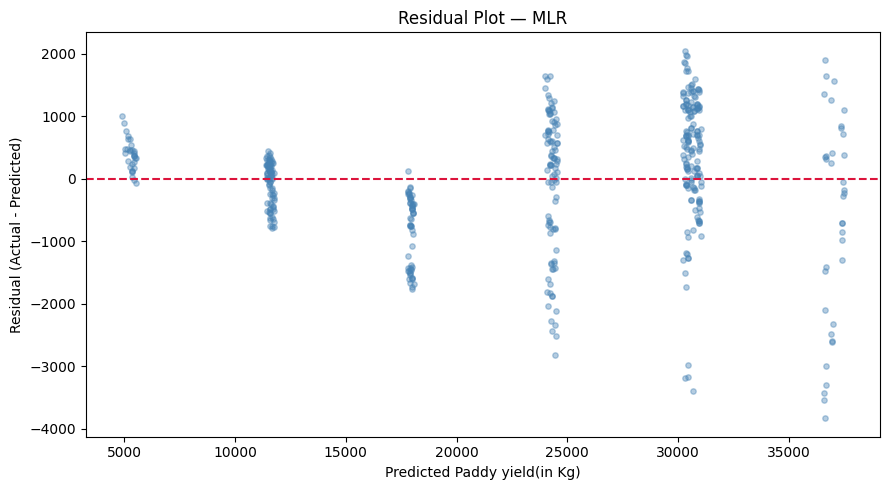

In [19]:
# Step 19 — Residual Analysis (MLR)

residuals = y_test_mlr.values - y_pred_mlr

plt.figure(figsize=(9, 5))
plt.scatter(y_pred_mlr, residuals, alpha=0.4, s=15, color="steelblue")
plt.axhline(0, color="crimson", linestyle="--")
plt.xlabel(f"Predicted {TARGET_COL}")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot — MLR")
plt.tight_layout()
plt.show()


Metric          SLR          MLR
   MAE 7.625976e+02 7.683663e+02
   MSE 1.068464e+06 1.040176e+06
  RMSE 1.033665e+03 1.019890e+03
    R² 9.875194e-01 9.878498e-01

RMSE improvement of MLR over SLR: 1.33%


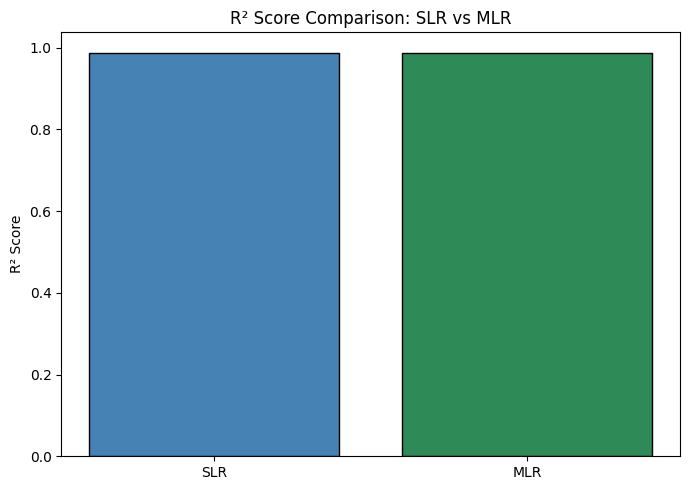

In [20]:
# Step 20 — Model Comparison: SLR vs MLR

results_table = pd.DataFrame({
    "Metric"     : ["MAE", "MSE", "RMSE", "R²"],
    "SLR"        : [mae_slr, mse_slr, rmse_slr, r2_slr],
    "MLR"        : [mae_mlr, mse_mlr, rmse_mlr, r2_mlr],
})
print(results_table.to_string(index=False))

pct_gain = (rmse_slr - rmse_mlr) / rmse_slr * 100
print(f"\nRMSE improvement of MLR over SLR: {pct_gain:.2f}%")

plt.figure(figsize=(7, 5))
plt.bar(["SLR", "MLR"], [r2_slr, r2_mlr],
        color=["steelblue", "seagreen"], edgecolor="black")
plt.ylabel("R² Score")
plt.title("R² Score Comparison: SLR vs MLR")
plt.tight_layout()
plt.show()


# Conclusion

- **Key Observations**
  - Using only cultivated area (`Hectares`) in SLR establishes a simple linear baseline but fails to account for other important cultivation variables such as soil type, seed rate, manure quantity, and paddy variety.
  - MLR, which combines multiple numeric inputs with one-hot encoded categorical features, captures a larger share of the variance in the target variable and delivers a **better R² and lower RMSE** compared to SLR.
  - The standardised coefficients from Step 17 reveal which cultivation factors — whether numeric inputs or specific soil/variety categories — exert the greatest influence on the predicted output.

- **Accuracy Achieved**
  - Refer to the metrics printed in Step 20 for the exact R² and RMSE improvement values after running the notebook. Ensure `TARGET_COL` matches the column specified by the faculty.

- **Limitations**
  - The target column is auto-detected using keyword matching since the UCI preview does not list all 45 columns; manual verification of `TARGET_COL` is recommended.
  - High-cardinality categorical columns are excluded from one-hot encoding to prevent feature explosion, which may result in some information loss.
  - Linear regression assumes a linear relationship between predictors and the target; agricultural effects like diminishing returns from fertilisers are inherently non-linear.

- **Future Directions**
  - Apply Ridge or Lasso regularisation to manage the larger feature space produced by one-hot encoding and reduce overfitting risk.
  - Evaluate ensemble methods such as Random Forest or Gradient Boosting, which handle non-linear relationships and categorical interactions more effectively.
  - Perform systematic feature selection to identify the most impactful cultivation factors, similar to the wrapper-based selection approach described in the original dataset paper.
